# Project Name : Develop a predictive model to accurately forecast hourly traffic volumes at different road junctions based on historical traffic data

## Component 5 - Data Modelling & Model Evaluation

### 1. Importing required libraries & Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Traffic_Dataset_Preprocessed_FeatureEngineered_Yashas.csv', parse_dates=['DateTime'])
df = df.sort_values(['Junction', 'DateTime']).reset_index(drop=True)
df.head()

,DateTime,Junction,Vehicles,temperature_c,humidity_pct,precipitation_mm,rain_mm,wind_speed_kmh,is_holiday,is_event_day,is_special_day,hour,day_of_week,is_weekend,month,is_rush_hour,vehicles_lag_1h,vehicles_lag_24h,vehicles_lag_168h,vehicles_roll_mean_3h
0,2015-11-08 00:00:00,1,13,19.9,89.0,0.0,0.0,8.8,0,0,0,0,6,1,11,0,15.0,16.0,15.0,16.000000
1,2015-11-08 01:00:00,1,16,19.6,91.0,0.0,0.0,9.1,0,0,0,1,6,1,11,0,13.0,16.0,13.0,14.666667
2,2015-11-08 02:00:00,1,11,19.4,91.0,0.0,0.0,9.3,0,0,0,2,6,1,11,0,16.0,10.0,10.0,14.666667
3,2015-11-08 03:00:00,1,8,18.9,92.0,0.0,0.0,10.7,0,0,0,3,6,1,11,0,11.0,9.0,7.0,13.333333
4,2015-11-08 04:00:00,1,10,18.7,91.0,0.0,0.0,10.7,0,0,0,4,6,1,11,0,8.0,8.0,9.0,11.666667


### 2. Time-based train/validation split

In [2]:
cutoff_date = df['DateTime'].quantile(0.8, interpolation='nearest')
print("Cutoff date:", cutoff_date)

train_df = df[df['DateTime'] <= cutoff_date].copy()
val_df   = df[df['DateTime']  > cutoff_date].copy()

print(f"Train: {train_df.shape[0]} rows ({train_df.DateTime.min()} to {train_df.DateTime.max()})")
print(f"Val:   {val_df.shape[0]} rows ({val_df.DateTime.min()} to {val_df.DateTime.max()})")

feature_cols = ['temperature_c','humidity_pct','precipitation_mm','rain_mm','wind_speed_kmh',
                'is_holiday','is_event_day','is_special_day',
                'hour','day_of_week','is_weekend','month','is_rush_hour',
                'vehicles_lag_1h','vehicles_lag_24h','vehicles_lag_168h','vehicles_roll_mean_3h','Junction']
target_col = 'Vehicles'

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_val,   y_val   = val_df[feature_cols],   val_df[target_col]

Cutoff date: 2017-03-24 03:00:00
Train: 37960 rows (2015-11-08 00:00:00 to 2017-03-24 03:00:00)
Val:   9488 rows (2017-03-24 04:00:00 to 2017-06-30 23:00:00)


### 3. Model 1 — Gradient Boosting (primary model)

In [3]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

gbm_baseline = XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
gbm_baseline.fit(X_train, y_train)
pred_val = gbm_baseline.predict(X_val)

def report_metrics(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"[{label}] MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.4f}")
    return mae, rmse, r2

baseline_metrics = report_metrics(y_val, pred_val, "GBM baseline - validation")

[GBM baseline - validation] MAE=2.874  RMSE=4.772  R2=0.9693


### 4. Hyperparameter tuning (time-series-aware)

In [4]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

param_dist = {
    'n_estimators': [200, 300, 400, 600],
    'max_depth': [3, 4, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=15, scoring='neg_mean_absolute_error',
    cv=tscv, random_state=42, n_jobs=-1, verbose=1
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV MAE:", -search.best_score_)

gbm_tuned = search.best_estimator_
pred_val_tuned = gbm_tuned.predict(X_val)
tuned_metrics = report_metrics(y_val, pred_val_tuned, "GBM tuned - validation")

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params: {'subsample': 0.8, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Best CV MAE: 2.8439881086349486
[GBM tuned - validation] MAE=2.901  RMSE=4.730  R2=0.9698


### 5. Cross-validation results analysis

In [5]:
from sklearn.model_selection import cross_val_score

cv_mae = -cross_val_score(gbm_tuned, X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_rmse = np.sqrt(-cross_val_score(gbm_tuned, X_train, y_train, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1))

print("Per-fold MAE:", np.round(cv_mae, 3))
print(f"Mean MAE: {cv_mae.mean():.3f}  Std: {cv_mae.std():.3f}")
print("Per-fold RMSE:", np.round(cv_rmse, 3))
print(f"Mean RMSE: {cv_rmse.mean():.3f}  Std: {cv_rmse.std():.3f}")

Per-fold MAE: [4.876 1.897 1.972 2.799 2.676]
Mean MAE: 2.844  Std: 1.078
Per-fold RMSE: [7.7   2.432 2.512 4.934 5.043]
Mean RMSE: 4.524  Std: 1.947


### 6. Diagnostic visualizations

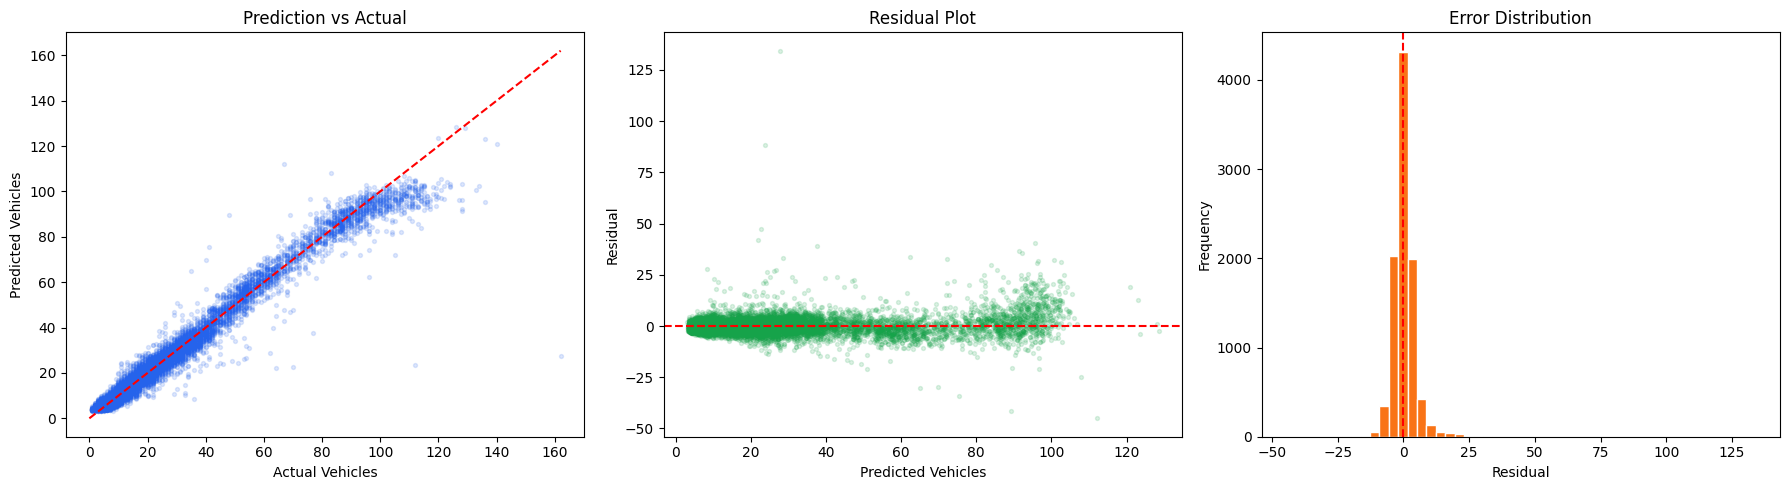

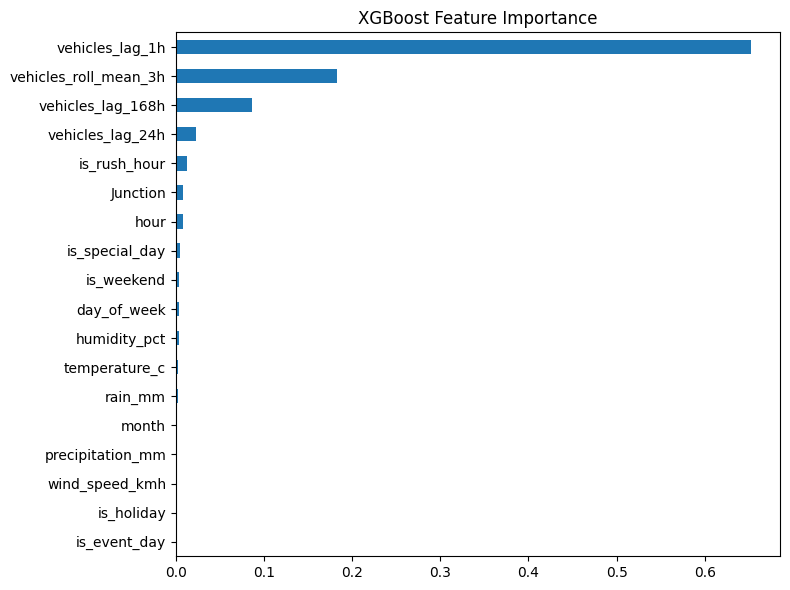

,0
vehicles_lag_1h,0.652736
vehicles_roll_mean_3h,0.182843
vehicles_lag_168h,0.086908
vehicles_lag_24h,0.023070
is_rush_hour,0.012509
Junction,0.007893
hour,0.007861
is_special_day,0.004355
is_weekend,0.003908
day_of_week,0.003717


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].scatter(y_val, pred_val_tuned, alpha=0.15, s=8, color='#2563eb')
lims = [0, max(y_val.max(), pred_val_tuned.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Vehicles'); axes[0].set_ylabel('Predicted Vehicles')
axes[0].set_title('Prediction vs Actual')

residuals = y_val.values - pred_val_tuned
axes[1].scatter(pred_val_tuned, residuals, alpha=0.15, s=8, color='#16a34a')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Vehicles'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

axes[2].hist(residuals, bins=50, color='#f97316', edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Frequency')
axes[2].set_title('Error Distribution')

plt.tight_layout()
plt.savefig('gbm_diagnostics.png', dpi=150)
plt.show()

importances = pd.Series(gbm_tuned.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8,6))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('gbm_feature_importance.png', dpi=150)
plt.show()
importances

### 7. Model 2 — ARIMA (per-junction baseline)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


[ARIMA(2,0,2) - Junction 1] MAE=28.616  RMSE=36.037  R2=-1.3128


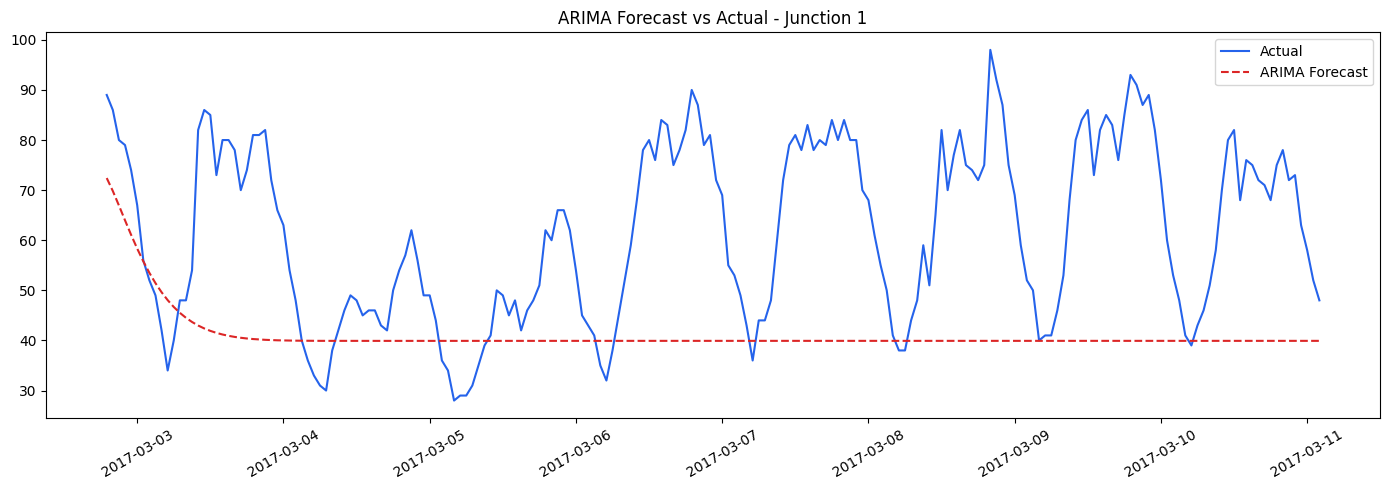

In [7]:
from statsmodels.tsa.arima.model import ARIMA

junction_id = 1
series = df[df.Junction == junction_id].set_index('DateTime')['Vehicles']
split_point = int(len(series) * 0.8)
train_series, val_series = series.iloc[:split_point], series.iloc[split_point:]

arima_fit = ARIMA(train_series, order=(2,0,2)).fit()
arima_pred = arima_fit.forecast(steps=len(val_series))
report_metrics(val_series.values, arima_pred.values, f"ARIMA(2,0,2) - Junction {junction_id}")

plt.figure(figsize=(14,5))
plt.plot(val_series.index[:200], val_series.values[:200], label='Actual', color='#2563eb')
plt.plot(val_series.index[:200], arima_pred.values[:200], label='ARIMA Forecast', color='#dc2626', linestyle='--')
plt.title(f'ARIMA Forecast vs Actual - Junction {junction_id}')
plt.legend(); plt.xticks(rotation=30); plt.tight_layout()
plt.savefig('arima_forecast_vs_actual.png', dpi=150);
plt.show()

### 8. Model 3 — LSTM (run this cell in Colab with GPU runtime enabled)

Epoch 1/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 0.0089 - val_loss: 0.0062
Epoch 2/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0036 - val_loss: 0.0050
Epoch 3/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0030 - val_loss: 0.0048
Epoch 4/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.0027 - val_loss: 0.0040
Epoch 5/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - loss: 0.0023 - val_loss: 0.0032
Epoch 6/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 0.0019 - val_loss: 0.0027
Epoch 7/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - loss: 0.0017 - val_loss: 0.0022
Epoch 8/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0017 - val_loss: 0.0021
Epoch 9/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - loss: 0.0016 - val_loss: 0.0020
Epoch 10/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.0015 - val_loss: 0.0020
Epoch 11/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - loss: 0.0014 - val_loss: 0.0020
Epoch 12/30
180/180 ━━━━━━━━━━━━━━━━━━━

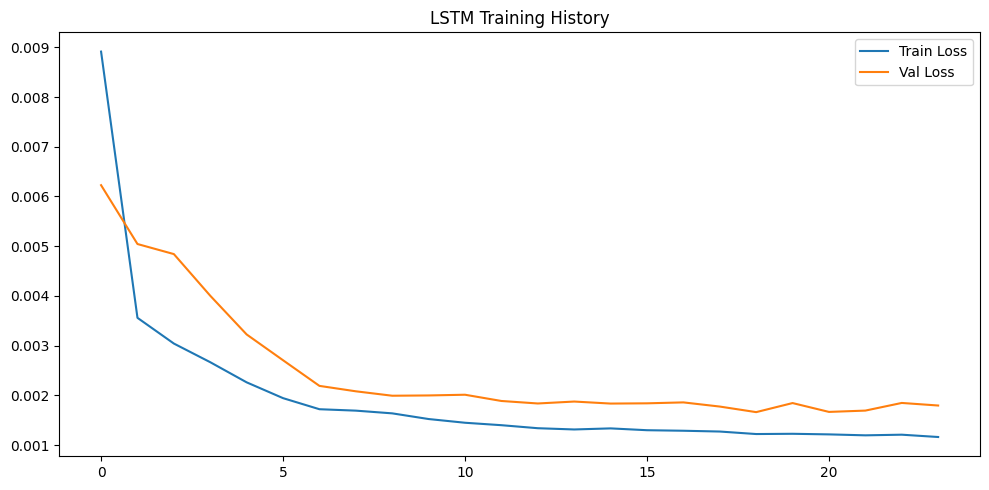

In [8]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

series_lstm = df[df.Junction == junction_id].sort_values('DateTime')['Vehicles'].values.reshape(-1,1)
scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series_lstm)

def make_sequences(data, window=24):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0]); y.append(data[i, 0])
    return np.array(X), np.array(y)

WINDOW = 24
X_seq, y_seq = make_sequences(series_scaled, WINDOW)
X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)

split = int(len(X_seq) * 0.8)
X_train_seq, X_val_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_val_seq = y_seq[:split], y_seq[split:]

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

history = lstm_model.fit(
    X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq),
    epochs=30, batch_size=64,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

lstm_pred = scaler.inverse_transform(lstm_model.predict(X_val_seq))
y_val_actual = scaler.inverse_transform(y_val_seq.reshape(-1,1))
report_metrics(y_val_actual, lstm_pred, f"LSTM - Junction {junction_id}")

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training History'); plt.legend()
plt.tight_layout(); plt.savefig('lstm_training_history.png', dpi=150); plt.show()

### 9. Model comparison

In [ ]:
comparison = pd.DataFrame({
    'Model': ['GBM Baseline', 'GBM Tuned', f'ARIMA (Junction {junction_id})', f'LSTM (Junction {junction_id})'],
    'MAE':  [baseline_metrics[0], tuned_metrics[0], None, None],
    'RMSE': [baseline_metrics[1], tuned_metrics[1], None, None],
    'R2':   [baseline_metrics[2], tuned_metrics[2], None, None],
})
comparison

### 10. Refinement — diagnose, refine features, retrain

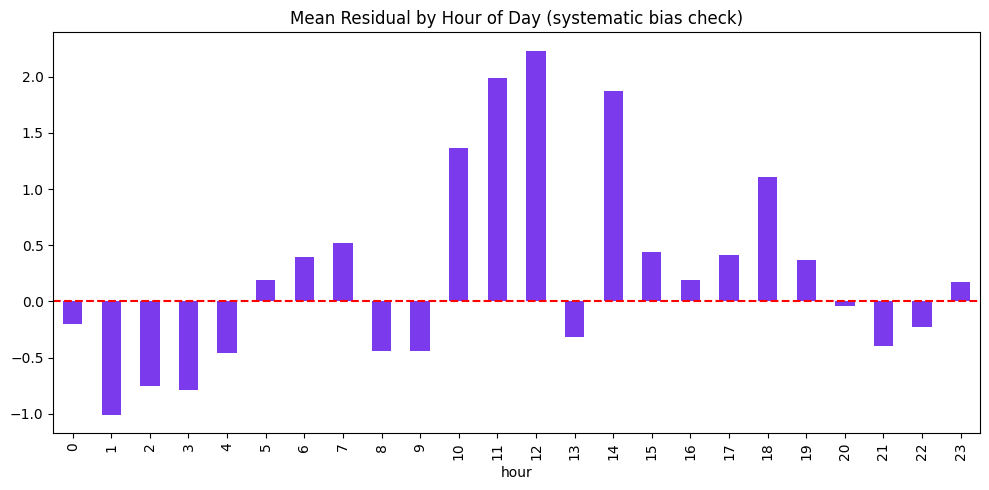

Refined feature set: ['vehicles_lag_1h', 'vehicles_roll_mean_3h', 'vehicles_lag_168h', 'vehicles_lag_24h', 'is_rush_hour', 'Junction', 'hour', 'is_special_day', 'is_weekend', 'day_of_week', 'humidity_pct', 'temperature_c']
[GBM refined (top features) - validation] MAE=2.861  RMSE=4.612  R2=0.9713

Compare to tuned (full feature set): (2.901150703430176, np.float64(4.729716511269734), 0.9697955846786499)


In [9]:
val_df_copy = val_df.copy()
val_df_copy['residual'] = y_val.values - pred_val_tuned
hourly_bias = val_df_copy.groupby('hour')['residual'].mean()

plt.figure(figsize=(10,5))
hourly_bias.plot(kind='bar', color='#7c3aed')
plt.axhline(0, color='red', linestyle='--')
plt.title('Mean Residual by Hour of Day (systematic bias check)')
plt.tight_layout(); plt.savefig('residual_bias_by_hour.png', dpi=150); plt.show()

top_features = importances.head(12).index.tolist()
print("Refined feature set:", top_features)

gbm_refined = XGBRegressor(**search.best_params_, random_state=42, n_jobs=-1)
gbm_refined.fit(X_train[top_features], y_train)
pred_val_refined = gbm_refined.predict(X_val[top_features])

refined_metrics = report_metrics(y_val, pred_val_refined, "GBM refined (top features) - validation")
print("\nCompare to tuned (full feature set):", tuned_metrics)